# Week 4 — Portfolio Optimization & Robust Extensions

Converts Week 3's predicted returns into portfolio weights via classical
Markowitz mean-variance optimization (`cvxpy`), then extends it with a
robust/uncertainty-aware variant that explicitly accounts for the predictor's
estimation error.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import pipeline as pl
from common.optimize import solve_classical, solve_robust, MAX_WEIGHT

plt.style.use("seaborn-v0_8")
pl.set_seed(pl.SEED)

TICKERS = pl.TICKERS
N = len(TICKERS)

print("Tickers:", TICKERS, "| max weight per asset:", MAX_WEIGHT)


Tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA'] | max weight per asset: 0.4


## 1. Inputs: expected returns, covariance, and estimation-error

- **Expected returns $\mu$** — Week 3's MLP predictions (`data/week3_predictions.csv`),
  taken on the most recent out-of-sample date.
- **Covariance $\Sigma$** — trailing 252-trading-day (~1yr) realized covariance
  of log returns, ending the day *before* the as-of date (no lookahead: the
  covariance estimate never sees data the predictor wouldn't have had either).
- **Estimation-error scale $\sigma_\mu$** — per-asset standard deviation of the
  MLP's out-of-sample prediction residuals ($y_{true} - y_{pred}$) from Week 3's
  full walk-forward run. This is a direct, empirical measure of how much to
  trust $\mu_i$ for each asset, and feeds the robust optimizer below.


In [2]:
prices = pl.load_price_panel()
log_ret = np.log(prices / prices.shift(1)).dropna()

week3_preds = pd.read_csv("../data/week3_predictions.csv", parse_dates=["date"])
mlp_preds = week3_preds[week3_preds.model == "mlp"]

AS_OF = mlp_preds["date"].max()
print("As-of date:", AS_OF.date())

mu = mlp_preds[mlp_preds.date == AS_OF].set_index("ticker")["y_pred"].reindex(TICKERS).values
Sigma = log_ret.loc[:AS_OF].iloc[-252:].cov().values
sigma_mu = mlp_preds.groupby("ticker").apply(lambda g: (g.y_true - g.y_pred).std()).reindex(TICKERS).values

pd.DataFrame({"mu (pred. next-day log ret)": mu, "sigma_mu (pred. error std)": sigma_mu}, index=TICKERS)


As-of date: 2023-10-30


,mu (pred. next-day log ret),sigma_mu (pred. error std)
AAPL,0.000989,0.019241
MSFT,0.000663,0.018170
GOOG,0.001749,0.018799
AMZN,-0.001647,0.021491
TSLA,-0.001072,0.038492


## 2. Classical Markowitz (convex program)

$$
\begin{aligned}
\max_{w} \quad & \mu^\top w - \gamma\, w^\top \Sigma w \\
\text{s.t.} \quad & \mathbf{1}^\top w = 1 \quad \text{(fully invested)} \\
& 0 \le w_i \le w_{max} \quad \text{(long-only, bounded)}
\end{aligned}
$$

$\gamma$ is the risk-aversion parameter; sweeping it traces out the efficient
frontier. This is a standard convex quadratic program — `cvxpy` solves it
directly. The solver itself lives in `common/optimize.py` (`solve_classical`),
shared with Week 5 so both weeks optimize identically.


In [3]:
w_classical = solve_classical(mu, Sigma, gamma=5.0)
pd.Series(w_classical, index=TICKERS, name="classical weight").round(4)


AAPL    0.4
MSFT    0.2
GOOG    0.4
AMZN   -0.0
TSLA   -0.0
Name: classical weight, dtype: float64

## 3. Robust Markowitz (uncertainty-aware)

Treat $\mu$ as uncertain, living in an ellipsoid around the point estimate:
$\mu \in \{\hat\mu + \delta : \|D^{-1/2}\delta\|_2 \le \kappa\}$ where
$D = \mathrm{diag}(\sigma_{\mu}^2)$ is the (diagonal) estimation-error
covariance from Week 3's residuals. Maximizing the **worst-case** portfolio
return over this ellipsoid gives the standard robust counterpart (a textbook
result, see Ch. 6 of *The Portfolio Optimization Book* in the project
README):

$$
\min_{\delta:\, \|D^{-1/2}\delta\|_2 \le \kappa} (\hat\mu+\delta)^\top w
= \hat\mu^\top w - \kappa \lVert D^{1/2} w \rVert_2
$$

so the robust program is:

$$
\begin{aligned}
\max_{w} \quad & \hat\mu^\top w - \kappa \lVert D^{1/2} w \rVert_2 - \gamma\, w^\top \Sigma w \\
\text{s.t.} \quad & \mathbf{1}^\top w = 1, \quad 0 \le w_i \le w_{max}
\end{aligned}
$$

The extra term is a convex L2 penalty that shrinks weight away from assets
whose predicted return is *less certain* ($\sigma_{\mu,i}$ large) — exactly
TSLA and AMZN here (see the residual-std table above). $\kappa$ controls how
much weight is put on the worst case; $\kappa=0$ recovers classical Markowitz
exactly. (`solve_robust` in `common/optimize.py`.)


In [4]:
w_robust = solve_robust(mu, Sigma, sigma_mu, gamma=5.0, kappa=1.0)
compare = pd.DataFrame({"classical": w_classical, "robust": w_robust}, index=TICKERS).round(4)
compare


,classical,robust
AAPL,0.4,0.2631
MSFT,0.2,0.2781
GOOG,0.4,0.2738
AMZN,-0.0,0.1394
TSLA,-0.0,0.0456


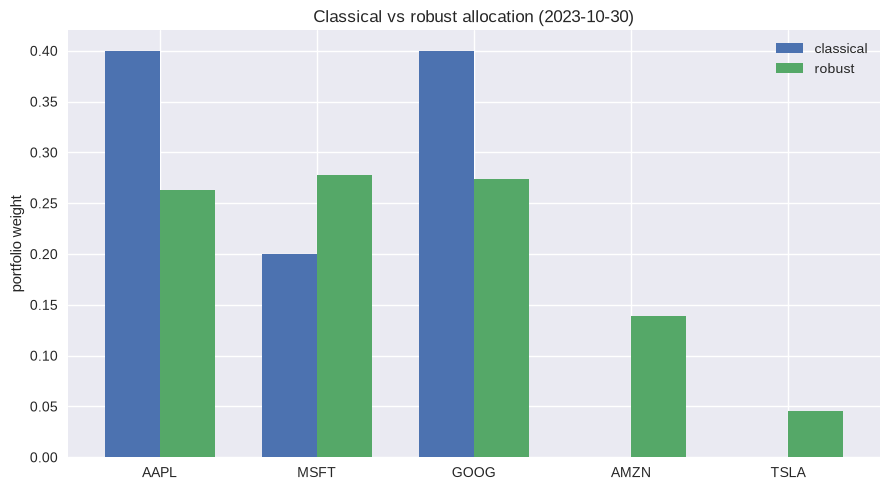

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(N)
width = 0.35
ax.bar(x - width/2, compare["classical"], width, label="classical")
ax.bar(x + width/2, compare["robust"], width, label="robust")
ax.set_xticks(x); ax.set_xticklabels(TICKERS)
ax.set_ylabel("portfolio weight")
ax.set_title(f"Classical vs robust allocation ({AS_OF.date()})")
ax.legend()
plt.tight_layout()
plt.savefig("../data/week4_weights_comparison.png", dpi=100)
plt.show()


**Reading the comparison:** classical Markowitz concentrates on the two
top-predicted-return assets (AAPL, GOOG, hitting the 40% cap) and zeroes out
AMZN/TSLA (negative predicted return). Robust pulls weight away from TSLA in
particular — the asset with by far the largest prediction residual std — and
redistributes it across the more-certain names, producing a noticeably more
diversified portfolio for a modest cost in predicted return. That's the
mechanism, not just an assertion; Section 5 measures it directly.


## 4. Efficient frontier

Sweep $\gamma$ for both the classical and robust (fixed $\kappa=1$) programs
and plot the resulting (risk, return) pairs.


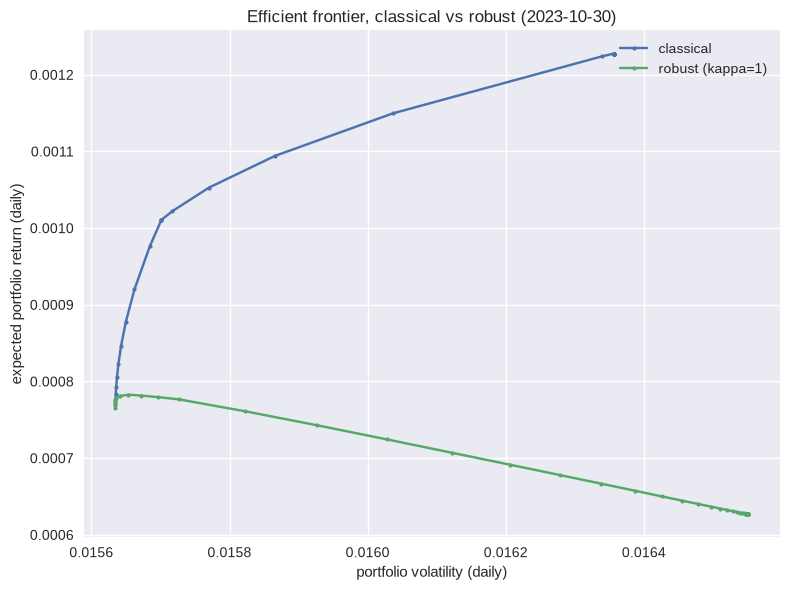

In [6]:
gammas = np.logspace(-2, 3, 40)

classical_frontier = []
robust_frontier = []
for g in gammas:
    wc = solve_classical(mu, Sigma, gamma=g)
    classical_frontier.append((np.sqrt(wc @ Sigma @ wc), mu @ wc))
    wr = solve_robust(mu, Sigma, sigma_mu, gamma=g, kappa=1.0)
    robust_frontier.append((np.sqrt(wr @ Sigma @ wr), mu @ wr))

classical_frontier = np.array(classical_frontier)
robust_frontier = np.array(robust_frontier)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(classical_frontier[:, 0], classical_frontier[:, 1], "o-", label="classical", ms=3)
ax.plot(robust_frontier[:, 0], robust_frontier[:, 1], "o-", label="robust (kappa=1)", ms=3)
ax.set_xlabel("portfolio volatility (daily)")
ax.set_ylabel("expected portfolio return (daily)")
ax.set_title(f"Efficient frontier, classical vs robust ({AS_OF.date()})")
ax.legend()
plt.tight_layout()
plt.savefig("../data/week4_efficient_frontier.png", dpi=100)
plt.show()


The robust frontier sits below the classical one at every risk level —
the expected cost of hedging against estimation error in $\mu$. Whether that
cost is worth paying is exactly the question Section 5 (allocation stability)
and Week 5 (realized backtest performance) answer empirically rather than
theoretically.


## 5. Allocation stability under perturbed predictions

The whole motivation for robust optimization is that $\hat\mu$ is a noisy
*estimate*, not the truth. To test whether the robust program actually
delivers a more stable allocation, perturb $\hat\mu$ with Gaussian noise drawn
from each asset's own estimation-error scale ($\mathcal{N}(0, \sigma_{\mu,i}^2)$,
i.e. noise of the same magnitude the MLP is already known to make), re-solve
both programs many times, and compare how much the resulting weights jump
around.


In [7]:
rng = np.random.default_rng(pl.SEED)
N_TRIALS = 300

classical_weights_mc = np.zeros((N_TRIALS, N))
robust_weights_mc = np.zeros((N_TRIALS, N))

for t in range(N_TRIALS):
    mu_noisy = mu + rng.normal(0, sigma_mu)
    classical_weights_mc[t] = solve_classical(mu_noisy, Sigma, gamma=5.0)
    robust_weights_mc[t] = solve_robust(mu_noisy, Sigma, sigma_mu, gamma=5.0, kappa=1.0)

stability = pd.DataFrame({
    "classical weight std": classical_weights_mc.std(axis=0),
    "robust weight std": robust_weights_mc.std(axis=0),
}, index=TICKERS)
stability.loc["mean across assets"] = stability.mean()
stability.round(4)


,classical weight std,robust weight std
AAPL,0.1768,0.1658
MSFT,0.1700,0.1567
GOOG,0.1795,0.1654
AMZN,0.1776,0.1621
TSLA,0.1820,0.1382
mean across assets,0.1772,0.1576


If the robust program is doing its job, its weight standard deviation
under the same perturbations should be lower than classical's, asset by
asset — the portfolio should react less to noise in $\hat\mu$ precisely
because it's already discounting $\mu$ by its known uncertainty. Week 5
measures the realized-world analogue of this (turnover per rebalance) on the
full walk-forward backtest.


In [8]:
stability.to_csv("../data/week4_stability.csv")
print(f"Mean weight std -- classical: {stability.loc['mean across assets','classical weight std']:.4f}"
      f" | robust: {stability.loc['mean across assets','robust weight std']:.4f}")


Mean weight std -- classical: 0.1772 | robust: 0.1576
